# LangGraph + Tools
### Building Agents That Think, Act, and Loop

---

## The Problem With Linear Chains

In the previous notebook we built chains that always run in a fixed sequence:

```
input → prompt → llm → parser → output
```

This works well for simple tasks. But real agents need to:
- **Make decisions** (should I search the web or answer from memory?)
- **Use tools** (call a function, search an API, read a file)
- **Loop** (try again if the first answer isn't good enough)
- **Branch** (take different paths based on what the LLM says)

**LangGraph** solves this. It lets you build workflows as **directed graphs** — with nodes, edges, and conditional branching — powered by a shared state that flows through each step.

---

## What We'll Build

1. Simple tools with `@tool`
2. An LLM that can decide when to use tools (ReAct agent)
3. A LangGraph `StateGraph` with nodes, edges, and conditional routing
4. A complete research assistant that loops until it has enough information

---

## Core Mental Model: Graphs, Not Chains

```
         ┌──────────────────────────────────────────────┐
         │              StateGraph                       │
         │                                              │
  START ──► [agent node] ──► should use tool? ──YES──► [tool node] ──┐
                │                                                     │
               NO                                                     │
                │◄────────────────────────────────────────────────────┘
                ▼
              END
```

- **Nodes** are functions that receive state and return updates to state
- **Edges** define what happens next (fixed or conditional)
- **State** is a shared dict/TypedDict that flows through the entire graph
- The graph runs until it hits `END`

In [30]:
%load_ext dotenv
%dotenv ../../05_src/.env
%dotenv ../../05_src/.secrets

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


---
## Section 1: Tools

### What Is a Tool?

A **tool** is a Python function that an LLM can choose to call. You define the function, and LangChain makes it available to the model. The model:
1. Sees the tool's **name** and **description** (from your docstring)
2. Decides **whether** to call it based on the user's request
3. Decides **what arguments** to pass
4. Receives the result and continues reasoning

The `@tool` decorator is all you need. The function signature and docstring become the tool's schema.

### Rule: Write Descriptive Docstrings

The LLM uses your docstring to decide *when* to call the tool. A vague docstring = the LLM won't use the tool correctly.

In [31]:
from langchain_core.tools import tool
from typing import Optional
import math
import json

# --- Tool 1: Calculator ---
@tool
def calculator(expression: str) -> str:
    """
    Evaluates a mathematical expression and returns the result.
    Use this when you need to perform any arithmetic or mathematical calculation.
    Input should be a valid Python math expression like '2 + 2' or 'math.sqrt(144)'.
    """
    try:
        result = eval(expression, {"__builtins__": {}}, {"math": math})
        print("TESTE")
        return f"Result: {result}"
    except Exception as e:
        return f"Error evaluating expression: {str(e)}"

# --- Tool 2: CVE Lookup (simulated) ---
@tool
def lookup_cve(cve_id: str) -> str:
    """
    Looks up information about a CVE (Common Vulnerabilities and Exposures) by its ID.
    Use this when the user asks about a specific CVE number like CVE-2021-44228.
    Returns severity, CVSS score, and a brief description.
    """
    # Simulated CVE database — in real life, this would call the NVD API
    cve_db = {
        "CVE-2021-44228": {
            "name": "Log4Shell",
            "severity": "CRITICAL",
            "cvss": 10.0,
            "description": "Remote code execution in Apache Log4j2 via JNDI lookup.",
            "affected": "Apache Log4j2 2.0-beta9 through 2.15.0"
        },
        "CVE-2023-44487": {
            "name": "HTTP/2 Rapid Reset Attack",
            "severity": "HIGH",
            "cvss": 7.5,
            "description": "DDoS vulnerability in HTTP/2 protocol implementations.",
            "affected": "Multiple HTTP/2 server implementations"
        },
    }
    cve_upper = cve_id.upper().strip()
    if cve_upper in cve_db:
        data = cve_db[cve_upper]
        return json.dumps(data, indent=2)
    return f"CVE {cve_id} not found in local database."

# --- Tool 3: Get current timestamp ---
@tool
def get_current_time() -> str:
    """
    Returns the current date and time.
    Use this when the user asks what time or date it is.
    """
    from datetime import datetime
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print(" Tools defined")

# Inspect what the LLM sees about each tool
tools = [calculator, lookup_cve, get_current_time]
for t in tools:
    print(f"\n Tool: {t.name}")
    print(f"   Description: {t.description[:80]}..." if len(t.description) > 80 else f"   Description: {t.description}")
    print(f"   Args schema: {list(t.args.keys())}")

 Tools defined

 Tool: calculator
   Description: Evaluates a mathematical expression and returns the result.
Use this when you ne...
   Args schema: ['expression']

 Tool: lookup_cve
   Description: Looks up information about a CVE (Common Vulnerabilities and Exposures) by its I...
   Args schema: ['cve_id']

 Tool: get_current_time
   Description: Returns the current date and time.
Use this when the user asks what time or date...
   Args schema: []


In [32]:
import os
# to disable tracing - by defualt LangChain will try to send telemetry to LangSmith
os.environ["LANGCHAIN_TRACING_V2"] = "false"

In [33]:
# Tools are just functions — you can call them directly too
print(calculator.invoke({"expression": "math.sqrt(256)"}))
print()
print(lookup_cve.invoke({"cve_id": "CVE-2021-44228"}))
print()
print(get_current_time.invoke({}))

TESTE
Result: 16.0

{
  "name": "Log4Shell",
  "severity": "CRITICAL",
  "cvss": 10.0,
  "description": "Remote code execution in Apache Log4j2 via JNDI lookup.",
  "affected": "Apache Log4j2 2.0-beta9 through 2.15.0"
}

2026-04-29 18:59:47


---
## Section 2: Binding Tools to an LLM

To let the LLM use tools, you call `.bind_tools()` on the model. This sends the tool schemas to the API, allowing the model to return "I want to call tool X with these arguments" instead of a text response.

### What Happens When a Tool Is Called

The LLM doesn't actually *execute* your Python function. It just returns a **tool call request** inside an `AIMessage`. You are responsible for executing the tool and returning the result back to the LLM.

```
LLM → "call calculator({expression: '2+2'})" → YOU run it → result "4" → LLM continues
```

LangGraph automates this loop for you.

In [34]:
import os
from openai import OpenAI
from langchain_openai import ChatOpenAI



llm = ChatOpenAI(base_url='https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1',
                 model="gpt-4o-mini",   # Which model to use
                 temperature=0,        # 0 = deterministic, 1 = creative
                 api_key='any value',
                 default_headers={"x-api-key": os.getenv('API_GATEWAY_KEY')})



# Bind tools to the LLM — now it knows about our tools
llm_with_tools = llm.bind_tools(tools)

# Test: ask something that requires a tool
response = llm_with_tools.invoke("What is the square root of 1764?")

print("Response type:", type(response).__name__)
print("Content:", response.content)          # Empty — the LLM wants to call a tool
print("Tool calls:", response.tool_calls)     # THIS is where the tool call lives


Response type: AIMessage
Content: 
Tool calls: [{'name': 'calculator', 'args': {'expression': 'math.sqrt(1764)'}, 'id': 'call_pVxtdRiFmwfs7AXJqv01gfvp', 'type': 'tool_call'}]


In [35]:
# Inspect the tool call request
if response.tool_calls:
    tc = response.tool_calls[0]
    print("Tool the LLM wants to call:", tc["name"])
    print("Arguments it chose:", tc["args"])
    print("Call ID:", tc["id"])

Tool the LLM wants to call: calculator
Arguments it chose: {'expression': 'math.sqrt(1764)'}
Call ID: call_pVxtdRiFmwfs7AXJqv01gfvp


---
## Section 3: LangGraph — Building the Agent Graph

### Core Building Blocks

| Component | What It Does |
|-----------|-------------|
| `StateGraph` | The graph itself — you add nodes and edges to it |
| `State` (TypedDict) | The data that flows through the graph |
| **Node** | A Python function: `def my_node(state) → state update` |
| **Edge** | Connects one node to the next |
| **Conditional Edge** | A function decides which node to go to next |
| `add_messages` | A special reducer that appends messages (not overwrites) |

### The Standard Agent Pattern (ReAct)

The most common agent pattern is **ReAct** (Reason + Act):

1. **Agent node**: LLM sees the state and either (a) responds directly, or (b) decides to call a tool
2. **Tool node**: Executes whatever tool the LLM requested
3. **Back to Agent**: The tool result is added to messages, the LLM sees it and decides what to do next
4. **Stop**: When the LLM responds without tool calls → send to END

In [36]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# --- Define the State ---
# This TypedDict is the shared state that flows through every node
# 'messages' uses the special add_messages reducer:
#   - Instead of overwriting the list, it APPENDS new messages
#   - This is crucial — without it, each node would erase the conversation

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

print(" AgentState defined")
print("Fields:", list(AgentState.__annotations__.keys()))

 AgentState defined
Fields: ['messages']


In [37]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode

# --- Model ---
llm = ChatOpenAI(base_url='https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1',
                 model="gpt-4o-mini",   # Which model to use
                 temperature=0,        # 0 = deterministic, 1 = creative
                 api_key='any value',
                 default_headers={"x-api-key": os.getenv('API_GATEWAY_KEY')})



llm_with_tools = llm.bind_tools(tools)

# --- Node 1: Agent ---
# This node runs the LLM with whatever messages are in state.
# It returns the LLM's response, which gets appended to messages.
def agent_node(state: AgentState) -> dict:
    """
    The 'brain' of the agent. Runs the LLM.
    The LLM either:
    - Returns a text answer (no tool calls) → we'll route to END
    - Returns tool call requests → we'll route to tool_node
    """
    print(f"  [Agent] Processing {len(state['messages'])} messages")
    response = llm_with_tools.invoke(state["messages"])
    # Return a dict with keys matching AgentState
    # The add_messages reducer will append this to the existing list
    return {"messages": [response]}

# --- Node 2: Tools ---
# ToolNode is a prebuilt LangGraph node that:
# 1. Reads the last AIMessage to find tool call requests
# 2. Executes each requested tool
# 3. Returns ToolMessages with the results
tool_node = ToolNode(tools)

print(" Nodes defined")

 Nodes defined


In [38]:
from langgraph.graph import END

# --- Conditional Edge: Should we use tools or stop? ---
# This function examines the last message and decides what node to go to next
def should_use_tools(state: AgentState) -> str:
    """
    Router function for the conditional edge after the agent node.
    Returns the name of the next node to execute.
    """
    last_message = state["messages"][-1]
    
    # If the last message has tool_calls, the LLM wants to use a tool
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print(f"  [Router] LLM requested tool: {last_message.tool_calls[0]['name']}")
        return "tools"  # Go to the tool node
    
    # No tool calls → the LLM gave a final answer
    print("  [Router] LLM gave final answer → END")
    return END  # Stop the graph

print(" Router function defined")

 Router function defined


In [39]:
from langgraph.graph import StateGraph, START, END

# --- Assemble the Graph ---
builder = StateGraph(AgentState)

# Add nodes (name → function)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

# Add edges
# Fixed edge: START always goes to agent first
builder.add_edge(START, "agent")

# Conditional edge: after agent, call should_use_tools to decide
# The mapping dict tells LangGraph: if the function returns "tools" → go to tools node
#                                   if it returns END → end the graph
builder.add_conditional_edges(
    "agent",           # From this node
    should_use_tools,  # Call this function to get the next node name
    {"tools": "tools", END: END}  # Map return values to node names
)

# Fixed edge: after tools always go back to agent (loop!)
builder.add_edge("tools", "agent")

# Compile the graph into a runnable
graph = builder.compile()

print(" Graph compiled")
print("Nodes:", list(graph.nodes.keys()))

 Graph compiled
Nodes: ['__start__', 'agent', 'tools']


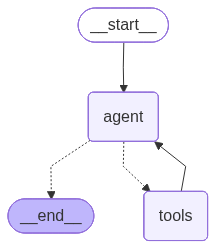

In [40]:
# Optional: visualize the graph structure (requires display in Jupyter)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Print Mermaid diagram code if display fails
    print(graph.get_graph().draw_mermaid())

---
## Section 4: Running the Agent

In [41]:
from langchain_core.messages import HumanMessage

def run_agent(question: str):
    """Run the agent graph with a user question and print the result."""
    print(f"\n{'='*60}")
    print(f"USER: {question}")
    print(f"{'='*60}")
    
    initial_state = {"messages": [HumanMessage(content=question)]}
    
    # .invoke() runs the graph to completion
    final_state = graph.invoke(initial_state)
    
    # The final answer is always the last message
    final_answer = final_state["messages"][-1].content
    
    print(f"\nAGENT: {final_answer}")
    print(f"\nTotal messages exchanged: {len(final_state['messages'])}")
    return final_state

In [42]:
# Test 1: Question that doesn't need a tool (LLM answers directly)
state = run_agent("What is the difference between authentication and authorization?")


USER: What is the difference between authentication and authorization?
  [Agent] Processing 1 messages
  [Router] LLM gave final answer → END

AGENT: Authentication and authorization are two fundamental concepts in the field of security, particularly in the context of information systems and applications. Here's a breakdown of the differences between the two:

### Authentication
- **Definition**: Authentication is the process of verifying the identity of a user, device, or system. It ensures that the entity requesting access is who they claim to be.
- **Methods**: Common methods of authentication include passwords, biometrics (fingerprints, facial recognition), security tokens, and multi-factor authentication (MFA).
- **Purpose**: The primary goal of authentication is to confirm the identity of the user or system before granting access to resources.

### Authorization
- **Definition**: Authorization is the process of determining whether an authenticated user has permission to access s

In [43]:
# Test 2: Question that requires the calculator tool
state = run_agent("If an attacker can make 1000 login attempts per minute, "
                  "how many hours would it take to try all combinations of a 4-digit PIN?")


USER: If an attacker can make 1000 login attempts per minute, how many hours would it take to try all combinations of a 4-digit PIN?
  [Agent] Processing 1 messages
  [Router] LLM requested tool: calculator
TESTE
  [Agent] Processing 3 messages
  [Router] LLM gave final answer → END

AGENT: It would take approximately 0.17 hours, or about 10 minutes, to try all combinations of a 4-digit PIN if an attacker can make 1000 login attempts per minute.

Total messages exchanged: 4


In [44]:
# Test 3: Question that requires the CVE lookup tool
state = run_agent("Tell me about CVE-2021-44228. What should I do about it?")


USER: Tell me about CVE-2021-44228. What should I do about it?
  [Agent] Processing 1 messages
  [Router] LLM requested tool: lookup_cve
  [Agent] Processing 3 messages
  [Router] LLM gave final answer → END

AGENT: CVE-2021-44228, also known as "Log4Shell," is a critical vulnerability with a CVSS score of 10.0. It allows for remote code execution in Apache Log4j2 via JNDI lookup. The affected versions are Apache Log4j2 from 2.0-beta9 through 2.15.0.

### Recommended Actions:
1. **Upgrade Log4j**: Immediately upgrade to Log4j version 2.16.0 or later, as these versions have patched the vulnerability.
2. **Mitigation**: If upgrading is not immediately possible, you can mitigate the risk by setting the system property `log4j2.formatMsgNoLookups` to `true` or by removing the JndiLookup class from the classpath.
3. **Monitor Systems**: Keep an eye on your systems for any unusual activity, as attackers may exploit this vulnerability.
4. **Review Logs**: Check your application logs for any s

In [45]:
# Test 4: Multi-step — requires multiple reasoning steps
state = run_agent("What time is it right now, and what is 2 to the power of 10?")


USER: What time is it right now, and what is 2 to the power of 10?
  [Agent] Processing 1 messages
  [Router] LLM requested tool: get_current_time
TESTE
  [Agent] Processing 4 messages
  [Router] LLM gave final answer → END

AGENT: The current time is 19:00:03 on April 29, 2026, and \(2\) to the power of \(10\) is \(1024\).

Total messages exchanged: 5


In [46]:
# Test 5: Multi-step — requires multiple reasoning steps
state = run_agent("What time is it right now? Calculate it from the \
                  timezone of Rio de janeiro.")


USER: What time is it right now? Calculate it from the                   timezone of Rio de janeiro.
  [Agent] Processing 1 messages
  [Router] LLM requested tool: get_current_time
  [Agent] Processing 3 messages
  [Router] LLM gave final answer → END

AGENT: The current time is 19:00:04 (7:00 PM) UTC. 

Rio de Janeiro is in the Brasília Time Zone (BRT), which is UTC-3. Therefore, the local time in Rio de Janeiro is 16:00:04 (4:00 PM).

Total messages exchanged: 4


In [ ]:
# Test 6: Multi-step — requires multiple reasoning steps
state = run_agent("Calciulate integral of x^2 dx from 0 to 10")


USER: Calciulate integral of x^2 dx from 0 to 10
  [Agent] Processing 1 messages
  [Router] LLM requested tool: calculator
  [Agent] Processing 3 messages
  [Router] LLM requested tool: calculator
TESTE
  [Agent] Processing 5 messages
  [Router] LLM gave final answer → END

AGENT: The integral of \( x^2 \, dx \) from 0 to 10 is approximately \( 333.33 \).

Total messages exchanged: 6


---
## Section 5: Streaming Graph Events

Instead of waiting for the entire graph to finish, you can **stream events** as they happen — great for seeing exactly what the agent is doing at each step.

In [47]:
from langchain_core.messages import HumanMessage

question = "Look up CVE-2023-44487 and calculate how many bytes are in 1 terabyte."

print(f"Streaming agent for: {question}")
print("=" * 60)

# .stream() yields events as each node finishes
for event in graph.stream(
    {"messages": [HumanMessage(content=question)]},
    stream_mode="updates"  # yields each node's output dict
):
    # event is a dict: { node_name: state_update }
    for node_name, update in event.items():
        print(f"\n => Node completed: [{node_name.upper()}]")
        for msg in update.get("messages", []):
            msg_type = type(msg).__name__
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                print(f"   → AI requested tool: {msg.tool_calls[0]['name']}")
                print(f"   → Args: {msg.tool_calls[0]['args']}")
            elif hasattr(msg, "content") and msg.content:
                content_preview = msg.content[:100] + "..." if len(msg.content) > 100 else msg.content
                print(f"   → {msg_type}: {content_preview}")

Streaming agent for: Look up CVE-2023-44487 and calculate how many bytes are in 1 terabyte.
  [Agent] Processing 1 messages
  [Router] LLM requested tool: lookup_cve

 => Node completed: [AGENT]
   → AI requested tool: lookup_cve
   → Args: {'cve_id': 'CVE-2023-44487'}
TESTE

 => Node completed: [TOOLS]
   → ToolMessage: {
  "name": "HTTP/2 Rapid Reset Attack",
  "severity": "HIGH",
  "cvss": 7.5,
  "description": "DDoS...
   → ToolMessage: Result: 1099511627776
  [Agent] Processing 4 messages
  [Router] LLM gave final answer → END

 => Node completed: [AGENT]
   → AIMessage: ### CVE-2023-44487
- **Name:** HTTP/2 Rapid Reset Attack
- **Severity:** HIGH
- **CVSS Score:** 7.5
...


---
## Section 6: Extra — Custom State & Multi-Step Workflow

The agent pattern above uses a simple `messages` state. For more complex workflows, you add custom fields to the state to track things like:
- A running summary
- Intermediate results
- Step count / iteration limit
- User preferences

Let's build a **Security Analysis Workflow** with richer state.

In [48]:
from typing import Annotated, Optional, List
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

# --- Richer state with custom fields ---
class AnalysisState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    cve_id: str                          # Input: which CVE to analyze
    cve_data: Optional[str]              # Tool result: raw CVE info
    severity_score: Optional[float]      # Extracted CVSS score
    analysis: Optional[str]              # LLM-generated analysis
    recommendations: Optional[List[str]] # Final recommendations
    step: int                            # Track progress

# --- Structured output for the analysis ---
class SecurityAnalysis(BaseModel):
    summary: str = Field(description="Brief summary of the vulnerability")
    risk_level: str = Field(description="Business risk level: LOW, MEDIUM, HIGH, CRITICAL")
    affected_organizations: str = Field(description="Types of organizations most at risk")
    recommendations: List[str] = Field(description="Prioritized list of 3-5 action items")
    timeline: str = Field(description="Recommended remediation timeline")

analysis_parser = PydanticOutputParser(pydantic_object=SecurityAnalysis)

# --- Model ---
llm = ChatOpenAI(base_url='https://k7uffyg03f.execute-api.us-east-1.amazonaws.com/prod/openai/v1',
                 model="gpt-4o-mini",   # Which model to use
                 temperature=0,        # 0 = deterministic, 1 = creative
                 api_key='any value',
                 default_headers={"x-api-key": os.getenv('API_GATEWAY_KEY')})


# --- Node 1: Fetch CVE Data ---
def fetch_cve_node(state: AnalysisState) -> dict:
    print(f"  [Step 1] Fetching CVE data for {state['cve_id']}")
    raw_data = lookup_cve.invoke({"cve_id": state["cve_id"]})
    
    # Extract CVSS score from the data if available
    import json
    try:
        parsed = json.loads(raw_data)
        cvss = parsed.get("cvss", None)
    except:
        cvss = None
    
    return {
        "cve_data": raw_data,
        "severity_score": cvss,
        "step": 1
    }

# --- Node 2: Analyze the CVE ---
def analyze_node(state: AnalysisState) -> dict:
    print(f"  [Step 2] Analyzing CVE data")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a senior cybersecurity analyst. Provide practical, actionable analysis.\n{format_instructions}"),
        ("human", "Analyze this vulnerability and provide a security assessment:\n\nCVE ID: {cve_id}\nData: {cve_data}")
    ]).partial(format_instructions=analysis_parser.get_format_instructions())
    
    chain = prompt | llm | analysis_parser
    
    analysis = chain.invoke({
        "cve_id": state["cve_id"],
        "cve_data": state["cve_data"]
    })
    
    return {
        "analysis": analysis.summary,
        "recommendations": analysis.recommendations,
        "step": 2
    }

# --- Node 3: Format Report ---
def report_node(state: AnalysisState) -> dict:
    print(f"  [Step 3] Generating final report")
    
    report = f"""# Security Analysis Report: {state['cve_id']}

## Summary
{state['analysis']}

## CVSS Score: {state['severity_score'] or 'N/A'}

## Recommendations
"""
    for i, rec in enumerate(state["recommendations"] or [], 1):
        report += f"  {i}. {rec}\n"
    
    return {
        "messages": [AIMessage(content=report)],
        "step": 3
    }

# --- Assemble the workflow graph ---
workflow = StateGraph(AnalysisState)
workflow.add_node("fetch", fetch_cve_node)
workflow.add_node("analyze", analyze_node)
workflow.add_node("report", report_node)

workflow.add_edge(START, "fetch")
workflow.add_edge("fetch", "analyze")
workflow.add_edge("analyze", "report")
workflow.add_edge("report", END)

analysis_graph = workflow.compile()
print("Analysis workflow graph compiled")

Analysis workflow graph compiled


In [49]:
# Run the multi-step analysis workflow
initial_state = {
    "messages": [],
    "cve_id": "CVE-2021-44228",
    "cve_data": None,
    "severity_score": None,
    "analysis": None,
    "recommendations": None,
    "step": 0
}

print("Running security analysis workflow...")
print("-" * 60)

final_state = analysis_graph.invoke(initial_state)

print("-" * 60)
print("\n" + final_state["messages"][-1].content)

Running security analysis workflow...
------------------------------------------------------------
  [Step 1] Fetching CVE data for CVE-2021-44228
  [Step 2] Analyzing CVE data
  [Step 3] Generating final report
------------------------------------------------------------

# Security Analysis Report: CVE-2021-44228

## Summary
CVE-2021-44228, also known as Log4Shell, is a critical vulnerability in Apache Log4j2 that allows for remote code execution through JNDI lookups, enabling attackers to execute arbitrary code on affected systems.

## CVSS Score: 10.0

## Recommendations
  1. Immediately upgrade Apache Log4j2 to version 2.16.0 or later to mitigate the vulnerability.
  2. Review and update all applications that utilize Log4j2 to ensure they are not using vulnerable versions.
  3. Implement network-level protections to block malicious JNDI requests.
  4. Monitor logs for any signs of exploitation attempts or unusual activity.
  5. Educate development and operations teams about secure

---
## Summary & Key Takeaways

| Concept | What It Is | Key Code |
|---------|-----------|----------|
| `@tool` | Decorator that turns a function into a LangChain tool | `@tool\ndef my_func(arg: str) -> str:` |
| `.bind_tools()` | Gives an LLM access to tools | `llm.bind_tools([tool1, tool2])` |
| `AgentState` | TypedDict that flows through the graph | `class AgentState(TypedDict): messages: ...` |
| `add_messages` | Annotation that appends instead of overwrites | `Annotated[list, add_messages]` |
| `StateGraph` | The graph builder | `builder = StateGraph(MyState)` |
| `add_node` | Register a function as a node | `builder.add_node("name", my_function)` |
| `add_conditional_edges` | Branch based on a router function | Decides next node at runtime |
| `ToolNode` | Prebuilt node that runs tools | `ToolNode(tools)` |
| `.stream()` | Watch events as they happen | `for event in graph.stream(state): ...` |

### The ReAct Pattern (What We Built)

```
START → [agent] → has tool calls? → YES → [tools] → [agent] → ...
                                  → NO  → END
```

### What's Next?

**MCP** — a protocol that lets you connect LangGraph agents to *external* tools and resources hosted by remote servers, without writing the tool integration code yourself.